# In-Class Assignment 16

**Due by the end of the day, Tuesday, 28 October, 2025**

# Estimating $H_0$ from Type Ia Supernovae

## Learning Objectives

- Explore the Phillips Relation using observational data.
- Practice plotting data with error bars and fitting to observational data.
- Using results of fitted data to compute cosmological parameters. 

Credit: [Michael Zingale](https://github.com/zingale/).

---

### Phillips relation

Type Ia supernova are used as standardizable candles to measure cosmological distances.  By observing the lightcurve and measuring how long it takes for the supernova to dim we can empirically determine its brightness via the [Phillips relation](https://en.wikipedia.org/wiki/Phillips_relationship).

The paper [_Spectra and Hubble Space Telescope Light Curves of Six Type Ia Supernovae at 0.511 < z < 1.12 and the Union2 Compilation_](https://ui.adsabs.harvard.edu/abs/2010ApJ...716..712A/abstract) by Amanullah et al. made a [data set available](https://supernova.lbl.gov/Union/figures/SCPUnion2_mu_vs_z.txt) that has ~ 500 Type Ia supernovae.

```{note}
That paper does a far, far more sophisticated analysis than we do, and they fit for other cosmological parameters that we will, so we will not get the same answer as they do.  But this is a fun dataset to try out regression with.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## a. - Sort and plot the data

**Describing the Data:**

The dataset has 4 columns:
* supernova identifier
* redshift, $z$, due to cosmological expansion
* [distance modulus](https://en.wikipedia.org/wiki/Distance_modulus), $\mu$, defined as:

  $$\mu = m - M = 5 \log_{10} \left (\frac{d}{10~\mbox{pc}}\right )$$

  where $m$ is the [apparent magnitude](https://en.wikipedia.org/wiki/Apparent_magnitude) of the
  supernova (what we observe) and $M$ is the [absolute magnitiude](https://en.wikipedia.org/wiki/Absolute_magnitude) of the supernova (inferred empirically from the lightcurve).
* uncertainty in $\mu$

## a. - Exploring the dataset and producing a Hubble diagram

Download the source data for this example [here](data/SCPUnion2_mu_vs_z.txt).

### **Individually/with the person next to you**:

1. Load the observational data using [`genfromtext`](https://numpy.org/doc/stable/reference/generated/numpy.genfromtxt.html).

2. Plot the distance modulus $\mu$ as a function of redshift $z$ with the errorbars $\delta \mu$ (`dmu` in our dataset) using [`plt.errorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html).

> You can compare this result to Figure 9 from the paper mentioned [above](https://iopscience.iop.org/article/10.1088/0004-637X/716/1/712#apj341188f9).

We can also make a plot that looks a bit more like a [Hubble diagram](https://en.wikipedia.org/wiki/Hubble%27s_law#Hubble_diagram) by plotting redshift vs. distance,
computing distance as:

$$d = 10 \cdot 10^{\mu/5}~\mathrm{pc}$$

3. Compute the distance using the above equation and our dataset.
4. Plot the redshift as a function of the computed distance (in Gpc) using a scatter plot to produce a _Hubble diagram_.


In [2]:
data = np.genfromtxt("data/SCPUnion2_mu_vs_z.txt",
                     dtype=[("name", "S6"), ("z", "f8"), ("mu", "f8"), ("dmu", "f8")])

Text(0.5, 0, 'Redshift $z$')

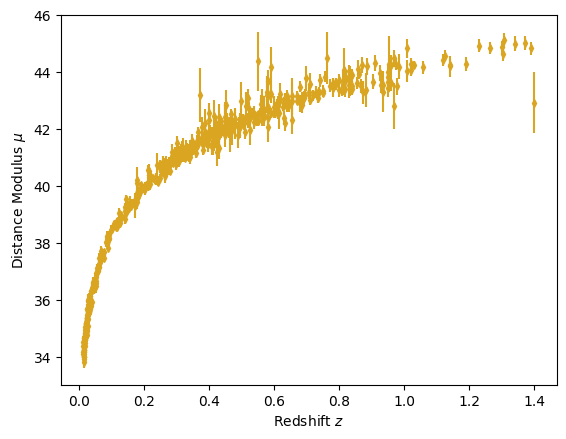

In [3]:
# 2 plot here
plt.errorbar(data['z'], data['mu'], yerr = data['dmu'], fmt = 'd',color='goldenrod',ms=4)
plt.ylabel('Distance Modulus $\mu$')
plt.xlabel('Redshift $z$')

Text(0.5, 0, 'Redshift $z$')

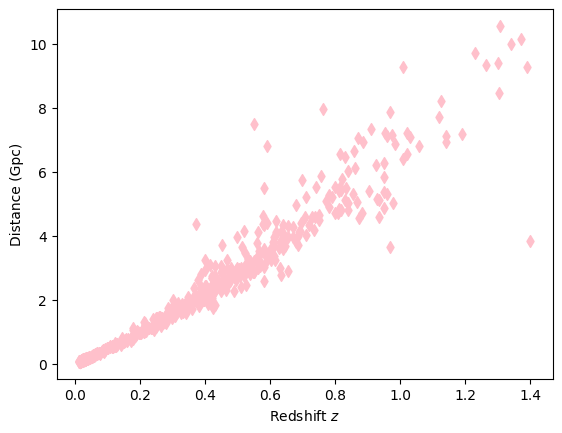

In [4]:
# 3-4 result here
d = 10 * 10**(data['mu']/5)
plt.scatter(data['z'], d/1e9,color='pink',marker='d')
plt.ylabel('Distance (Gpc)')
plt.xlabel('Redshift $z$')

### **With your larger group, try to answer the following**:

1. Comment qualitatively on the scatter of the measurements towards higher redshift. What might contribute to the scatter?

> At high redshift, measurement errors begin to dominate the data. 

2. Comment on the qualitative behavior of the sources in the Hubble diagram. Assuming $v=H_{0}d$, what can we say about the behaviour of the sources as a function of redshift?

> Objects at higher redshift are receeding faster than objects that are closer. 

### Cosmological parameters

We have the [distance modulus](https://en.wikipedia.org/wiki/Distance_modulus), which is related to the magnitudes via:

$$\mu = m - M = 5 \log_{10} \left (\frac{d}{10~\mbox{pc}}\right )$$

Since cosmologists usually work in terms of Mpc, let's rewrite this as:

$$\mu = m - M = 5 \log_{10} \left (\frac{d}{10~\mbox{pc}}\right ) 
    + 5 \log_{10} \left ( \frac{1~\mbox{Mpc}}{1~\mbox{Mpc}}\right )
    = 5 \log_{10} \left (\frac{d}{1~\mbox{Mpc}}\right ) + 25$$

Now, in an expanding Universe, the distance that goes here is the [luminosity distance](https://en.wikipedia.org/wiki/Luminosity_distance) which can be expressed via an expansion in redshift as (for $z \ll 1$):

$$d_L \approx \frac{c}{H_0} \left [ z + \frac{1}{2} (1 - q_0) z^2 + \ldots \right ]$$

Here $H_0$ is the [Hubble constant](https://en.wikipedia.org/wiki/Hubble%27s_law) and $q_0$ is the [deceleration parameter](https://en.wikipedia.org/wiki/Deceleration_parameter).

**We'll try to estimate $H_0$ from this data.**

```{note}
This is different than what the original paper did&mdash;they used a value of $H_0$ to find a $\Omega_m$ and $\Omega_\Lambda$ using the more general expression for luminosity distance given in [Perlmutter et al. 1997](https://ui.adsabs.harvard.edu/abs/1997ApJ...483..565P/abstract) (see footnote 14):

$$d_L(z; \Omega_M, \Omega_\Lambda, H_0) = \frac{c(1+z)}{H_0 \sqrt{|\kappa|}} 
  S\left ( \sqrt{|\kappa|} \int_0^z \left [(1 + z')^2(1 + \Omega_M z') - z'(2 + z')\Omega_\Lambda\right ]^{-1/2} dz' \right )$$

with $S(x)$ and $\kappa$ defined as:

* $\Omega_M + \Omega_\Lambda > 1$: $S(x) = \sin(x)$; $\kappa = 1 - \Omega_M - \Omega_\Lambda$
* $\Omega_M + \Omega_\Lambda = 1$: $S(x) = x$; $\kappa = 1$
* $\Omega_M + \Omega_\Lambda < 1$: $S(x) = \sinh(x)$; $\kappa = 1 - \Omega_M - \Omega_\Lambda$

Using this definition would require us to combine integration and fitting.
```

We want to fit:

$$\mu = 5\log_{10} \left (\frac{cz}{H_0 \cdot 1~\mbox{Mpc}} \left [1 + \frac{1}{2} (1 - q_0) z \right ] \right ) + 25$$

which we'll write as:

$$\boxed{\mu = 5\log_{10} \left (a_0 z \left [1 + \frac{1}{2} (1 - a_1) z \right ] \right ) + 25}$$

This is a nonlinear expression in terms of the fit parameters, $a_0$, $a_1$.  Once we get $a_0$, we can get Hubble's constant as:

$$\boxed{H_0 = \frac{c}{a_0 \cdot 1~\mbox{Mpc}}}$$

---

## b. - Fitting low redshift data to measure $H_{0}$

### **Individually/with the person next to you**:

1. First, use a mask to filter our data to only include data for $z < 0.2$. We will perform our fit on only this low redshift data. 

We'll use the SciPy fitting [routine](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html) via method of [Least Squares](https://en.wikipedia.org/wiki/Least_squares) for this.  Let's start by writing the [residual,the error in a result](https://en.wikipedia.org/wiki/Residual_(numerical_analysis)) that the fit will use.

```
def resid(avec, z, mu, dmu):
    return (mu - (5 * np.log10(avec[0] * z * (1 + 0.5 * (1 - avec[1]) * z)) + 25)) / dmu
```

2. import scipy optimize - `from scipy import optimize`
3. define the above residual
> Here, `avec` is a vector that holds the solutions of our fit - $a_{0}$ and $a_{1}$ from above.
4. Pass the inital guess data to the scipy routine, including the errors on mu - `dmu`. 
5. Use the `[0]` result to return $a_{0}$ from the fit to find $H_0$.
6. Plot the raw low redshift together, and overlay the estimated non-linear equation from c. and using the values returned from the fit. 

In [5]:
# 1 here
low_z_data = data[data['z'] < 0.2]

In [6]:
from scipy import optimize

In [7]:
# 3 here
def resid(avec, z, mu, dmu):
    return (mu - (5 * np.log10(avec[0] * z * (1 + 0.5 * (1 - avec[1]) * z)) + 25)) / dmu

In [8]:
# 4
c = 3.e5   # km/s 
H0_guess = 50   # km/s/Mpc

# convert guesses to the avec guesses needed
a0 = c / H0_guess
a1 = 1.

In [9]:
# 4 result here
result = optimize.least_squares(resid, np.array([a0,a1]), ## solve based on the residual, pass initial guesses 
                                args = (low_z_data['z'], low_z_data['mu'], low_z_data['dmu'])) ## pass low_z data

From this fit, we can recover the Hubble constant:

In [10]:
# 5 here
a0_result, a1_result = result.x
H0_result = c/a0_result
H0_result

69.64993800425839

We should find a reasonable value of $H_0 = 69.6~\mathrm{km/s/Mpc}$.

Text(0.5, 0, 'Redshift')

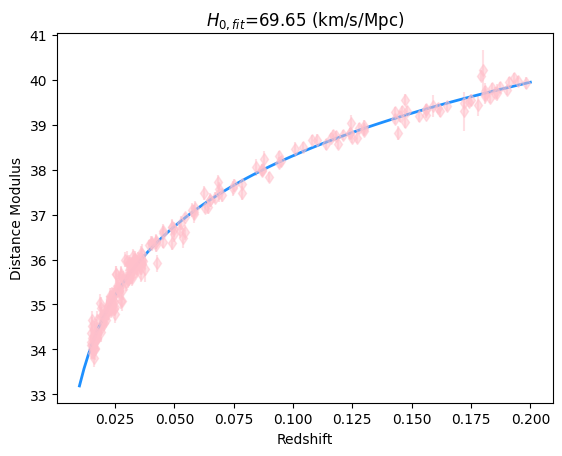

In [11]:
# 6 here
plt.title('$H_{0,fit}$='+str(round(H0_result,3))+' (km/s/Mpc)')

# plot raw data and fit data
plt.errorbar(low_z_data['z'], low_z_data['mu'], yerr = low_z_data['dmu'],fmt = 'd',color='pink',alpha=0.5)

# create redshift array for plotting the fit
z = np.linspace(0.01,0.2,100)

# our first boxed equation above
mu_fit = 5*np.log10(a0_result*z*(1+0.5*(1-a1_result)*z)) + 25
plt.plot(z,mu_fit,color='dodgerblue',lw=2)
plt.ylabel('Distance Modulus')
plt.xlabel('Redshift')

### **With your larger group, try to answer the following**:

1. What does it mean to to be used as a _Standard Candle_ in astronomy?

> Using the known luminosity of an observed and its observed brightness to determine its distance.

2. Are Type Ia supernovae considered _Standard Candles_ in astronomy? Why or why not?

> Yes, they have consistent peak brightnesses and this can be used to measure their distance and as such the expansion of the Universe, $H_0$.

3. What physically might contribute to the peak luminosity of a Type Ia supernovae?

> Hint: Chandrasehkar Mass limit

> The critical mass for ignition of a WD is mostly fixed by the Chandra mass limit thus fixing its peak brightness - the visual/apparament magnitude $m$ (the brightness of the event).